In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')
print(df.head())
print(df.shape)

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
Year                    0
Month                   0
Region                  0
Model                   0
Estima

In [4]:
le = LabelEncoder()
categorical_cols = ['Region','Model','Source_Type']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print(df.dtypes)

Year                      int64
Month                     int64
Region                    int64
Model                     int64
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type               int64
Charging_Stations         int64
dtype: object


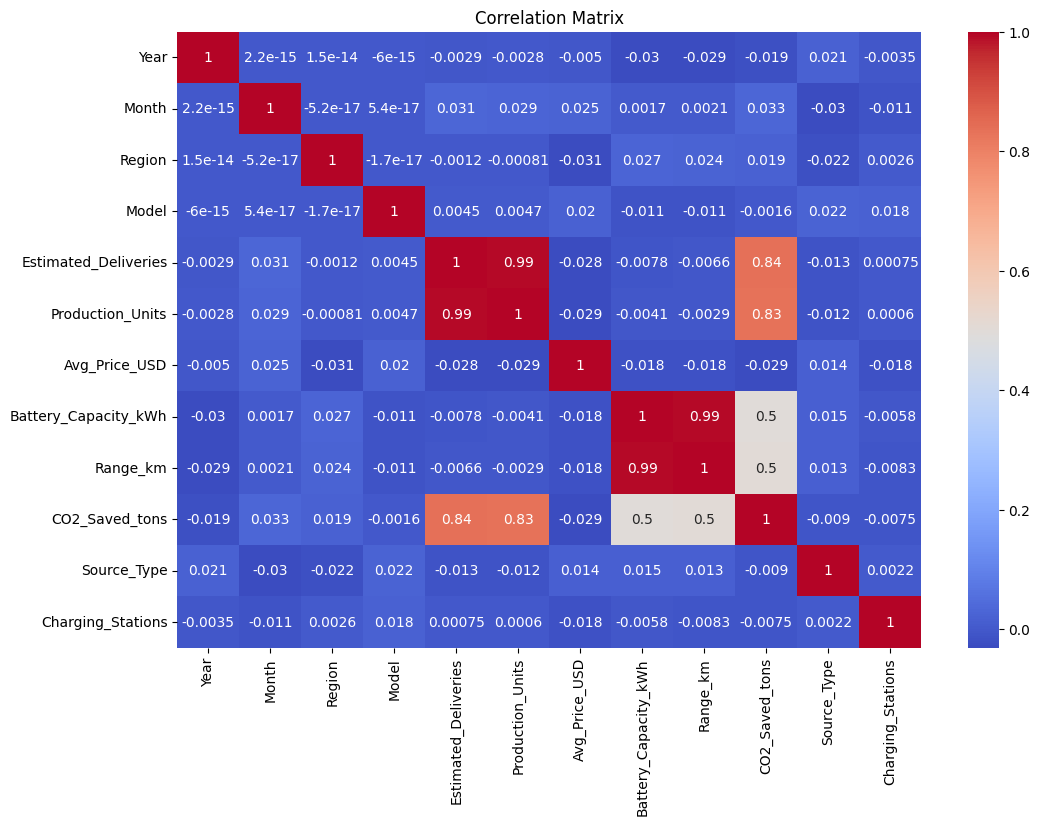

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

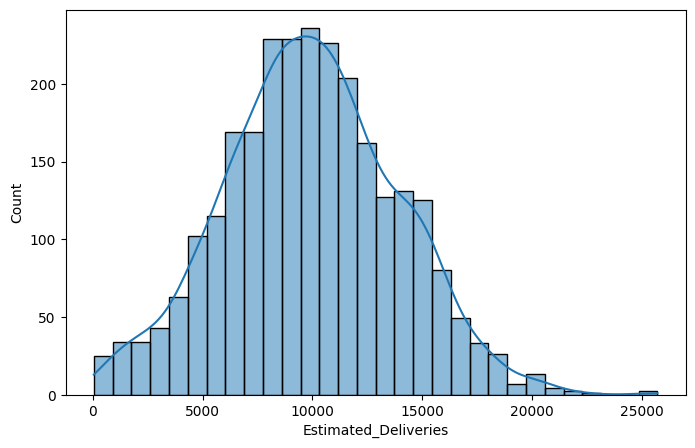

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True)
plt.show()

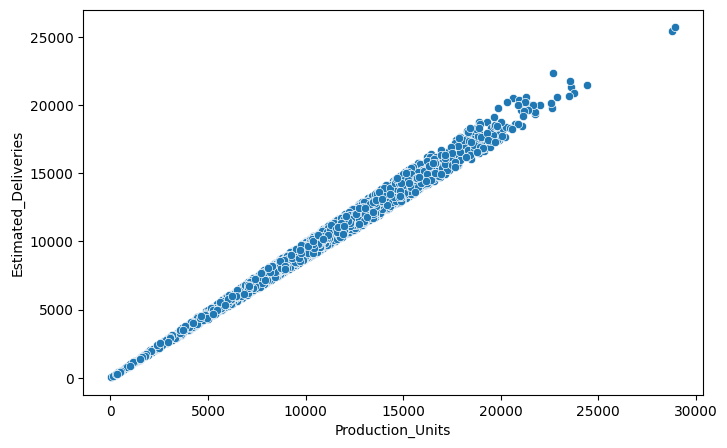

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Production_Units', y='Estimated_Deliveries', data=df)
plt.show()

In [8]:
df['Production_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']

In [9]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print('Linear Regression')
print('MAE:', mean_absolute_error(y_test, pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_lr)))
print('R2:', r2_score(y_test, pred_lr))

Linear Regression
MAE: 108.76917173561047
RMSE: 153.31081819326386
R2: 0.998423201888755


In [11]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
print('Ridge R2:', r2_score(y_test, pred_ridge))

Ridge R2: 0.9977712102456763


In [12]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)
print('Lasso R2:', r2_score(y_test, pred_lasso))

Lasso R2: 0.9984245726740778


In [13]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print('Random Forest')
print('MAE:', mean_absolute_error(y_test, pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_rf)))
print('R2:', r2_score(y_test, pred_rf))

Random Forest
MAE: 66.16706439393941
RMSE: 111.92588707632376
R2: 0.9991595892897444


In [14]:
params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


                  Feature  Importance
4        Production_Units    0.990349
11  Production_Efficiency    0.008686
8          CO2_Saved_tons    0.000269
5           Avg_Price_USD    0.000106
7                Range_km    0.000099
10      Charging_Stations    0.000096
1                   Month    0.000095
0                    Year    0.000087
3                   Model    0.000072
2                  Region    0.000066
9             Source_Type    0.000046
6    Battery_Capacity_kWh    0.000028


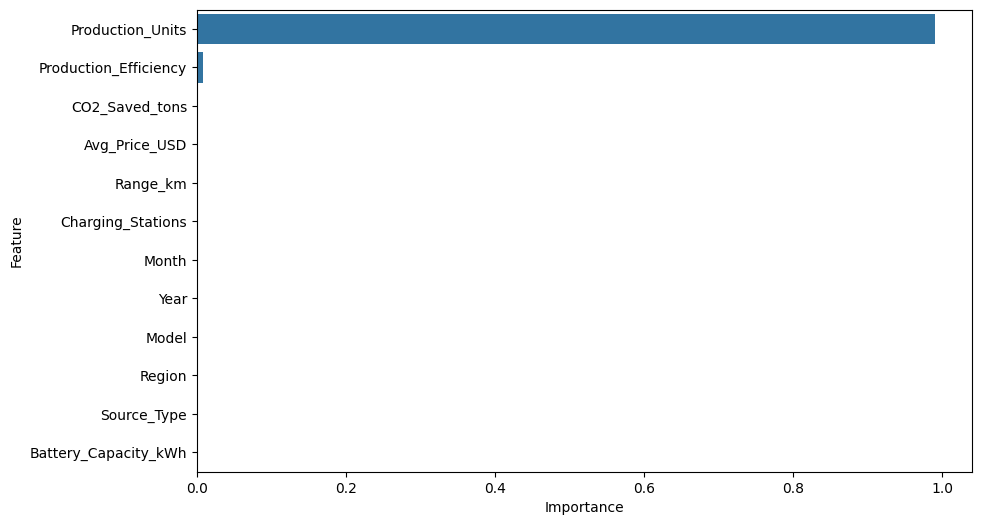

In [15]:
best_rf = grid.best_estimator_

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.show()

In [16]:
ts = df.groupby('Year')['Estimated_Deliveries'].sum()

model = ARIMA(ts, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)
print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

11    2.299894e+06
12    2.409983e+06
13    2.411338e+06
14    2.323992e+06
15    2.364693e+06
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


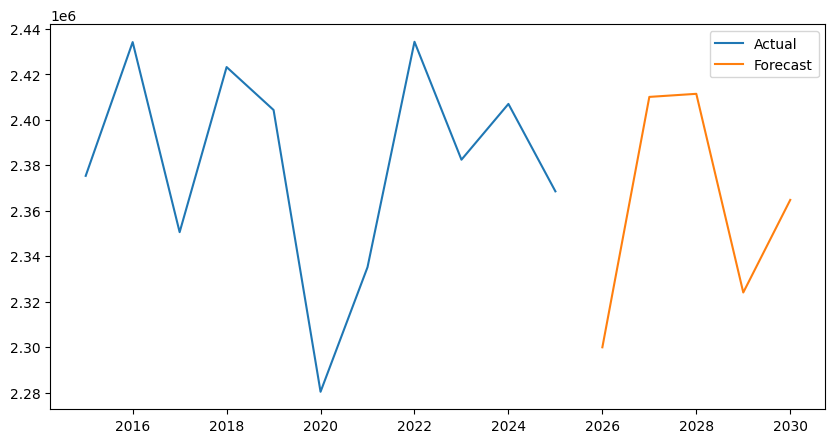

In [17]:
plt.figure(figsize=(10,5))
plt.plot(ts.index, ts.values, label='Actual')

future_years = [ts.index.max()+i for i in range(1,6)]
plt.plot(future_years, forecast, label='Forecast')

plt.legend()
plt.show()